In [1]:
%reset -f
from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet, Cstr
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize, least_squares


import logging

from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
df = process_roi_txt_to_excel("230816_M06_Au06_Primary.txt", "230816_M06_Au06_Primary.xlsx")

In [3]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

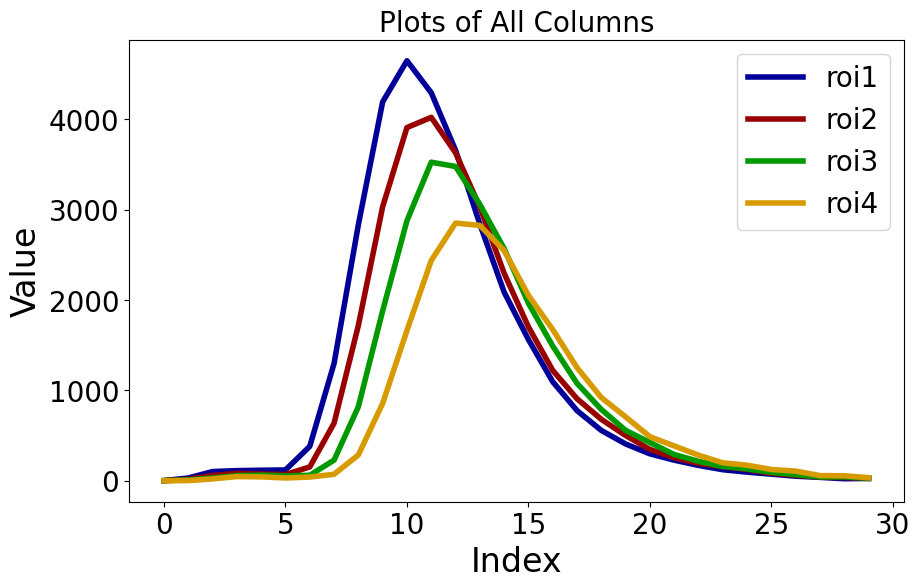

In [4]:
rois = plot_all_columns(data_unc[:,11:15])
xi=xi[11:15]

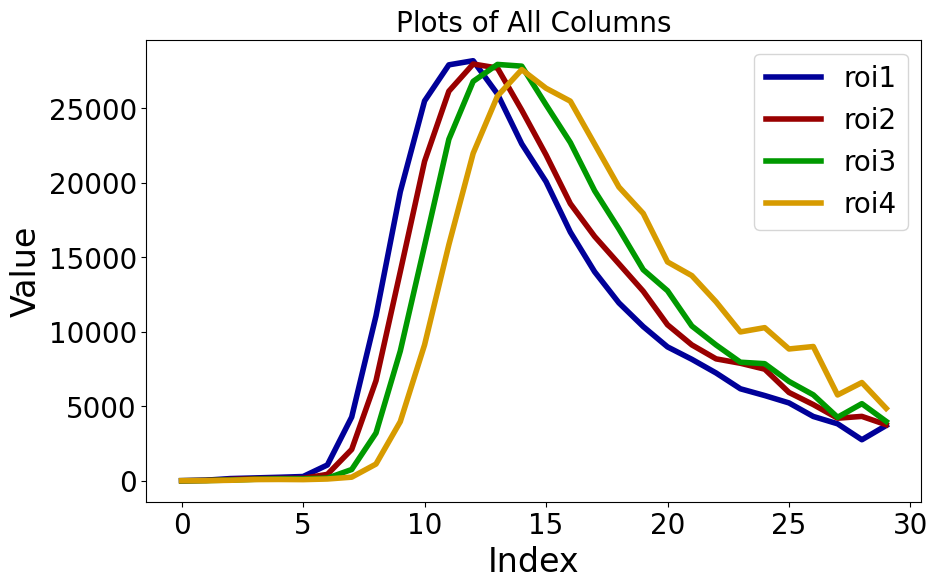

In [5]:
rois_cor = plot_all_columns(data_cor[:,11:15])

In [6]:
roi1 = rois['roi1']
roi2 = rois['roi2']
roi3 = rois['roi3']
roi4 = rois['roi4']


exp_data = np.hstack((roi1,roi2,roi3,roi4)).reshape(4,30).T
exp_data = exp_data / np.max(exp_data)

weights = 1 / np.mean(exp_data, axis=0)

In [7]:
xi

[130.54236580614878, 142.64215391942056, 154.9429455584124, 166.97113629995647]

In [8]:
xi[1]/1000-xi[0]/1000,  xi[2]/1000-xi[1]/1000, xi[3]/1000-xi[2]/1000

(0.012099788113271781, 0.012300791638991837, 0.01202819074154407)

In [9]:

def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct2_relA = x[1]
    p_mct3_relA = x[2]
    p_col_dispersion = x[3]
    p_t0 = x[4]
    
    
    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=1, name='mct1')
    mct2 = MCT(component_system, nchannel=1, name='mct2')
    mct3 = MCT(component_system, nchannel=1, name='mct3')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 20
    mct2.discretization.ncol = 20
    mct3.discretization.ncol = 20


    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system

    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(outlet)

    v_lrmp = 4e-05

    leaf.total_porosity = 9.20711785e-01
    leaf.length = 9.12398615e-02 
    leaf.diameter = x[0]/v_lrmp #np.sqrt(1/np.pi)
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, mct2, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, outlet, origin_port = 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[1]/1000-xi[0]/1000
    mct2.length =  xi[2]/1000-xi[1]/1000
    mct3.length =  xi[3]/1000-xi[2]/1000
    
    mct1.channel_cross_section_areas = [1]
    mct2.channel_cross_section_areas = [p_mct2_relA] 
    mct3.channel_cross_section_areas = [p_mct3_relA] 
    
    mct1.axial_dispersion = 0
    mct2.axial_dispersion = 0
    mct3.axial_dispersion = 0
    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0]],
                                    ])
    
    mct2.exchange_matrix = np.array([
                                    [[0.0]],
                                    ])
    mct3.exchange_matrix = np.array([
                                    [[0.0]],
                                    ])



    process.cycle_time = 60*t[-1]

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

In [10]:
# Define min and max values for each parameter

param_bounds = {
    'q_const': (1e-05, 1.5e-04),  # log-scaling
    'mct2_relA': (1,1.8),
    'mct3_relA': (1,1.8),
    'col_dispersion': (1e-09, 1e-06),                # log-scaling
    't0': (0.01, 20),   # linear scaling
}
        

def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")

In [11]:
def mct_obj(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]



    lenghts = [x / 1000 for x in xi]

    eval_location1 = [0]
    eval_location2 = [0]
    eval_location3 = [0] + [xi[3]/1000-xi[2]/1000]


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 =  np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 =  np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 =  np.sum(cb_mct3, axis=2).squeeze()




    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3))
    calc_data = calc_data/np.max(calc_data)

    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, SSQ)

    return SSQ

In [12]:
def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]



    lenghts = [x / 1000 for x in xi]

    eval_location1 = [0]
    eval_location2 = [0]
    eval_location3 = [0] + [xi[3]/1000-xi[2]/1000]


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 =  np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 =  np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 =  np.sum(cb_mct3, axis=2).squeeze()




    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3))
    calc_data = calc_data/np.max(calc_data)
    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, SSQ)

    return residuals

In [13]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)

    calc_data = calc_data/np.max(calc_data)
    
    res=np.sum(((calc_data.ravel()-exp_data.ravel())**2).reshape(exp_data.shape[0],exp_data.shape[1]),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time,calc_data, label="mct1", linewidth=1)
    plt.gca().set_prop_cycle(None)
    ax1.plot(time,res, label="res", color='b')
    ax1.plot(time,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)

def calculate_velocities(
    x_normalized,  
    area_indices
):
    """
    Calculate velocities in mm/min for a series of tubes based on normalized parameters.

    Parameters:
    - x_normalized: list or array, the normalized input vector.
    - denormalize_parameters: function, to denormalize the normalized parameters.
    - param_bounds: dict, the bounds of the parameters for denormalization.
    - area_indices: list of int, the indices in x_normalized corresponding to relative areas.

    Returns:
    - DataFrame with tube names, areas, and velocities in mm/min.
    """
    # Denormalize the parameters
    x_denormalized = denormalize_parameters(x_normalized)

    # Extract flow rate and relative areas
    flow_rate_m3_s = x_denormalized[0]  # Flow rate is always at index 0
    relative_areas = [x_denormalized[i] for i in area_indices]

    # Initial area is always 1
    initial_area = 1.0

    # Calculate absolute areas
    areas = [initial_area] + [initial_area * rel for rel in relative_areas]

    # Calculate velocities in mm/min
    velocities = [(flow_rate_m3_s / area) * 1e3 * 60 for area in areas]

    # Create table with results
    tube_names = ["Tube1"] + [f"mct{i+2}_relA" for i in range(len(relative_areas))]
    results = pd.DataFrame({
        "Tube": tube_names,
        "Area (m^2)": areas,
        "Velocity (mm/min)": velocities
    })

    return results

In [14]:
simulator = Cadet()    
simulator.time_resolution = 60
simulator.use_dll = False

In [15]:
analyze_parameters([0.33307913, 0.63933083, 0.25751792,
       0.5369973 , 0.84254536, 0.67613873])

Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
q_const                       5.66310782e-05      0.33      
mct2_relA                     1.51146466e+00      0.64      
mct3_relA                     1.20601434e+00      0.26      
col_dispersion                4.08311771e-08      0.54      
t0                            6.04320749e+00      0.84      


In [17]:
normalize_parameters([5.89289724e-05, 6.28191622e-07, 3.81099764e-07, 2.07416791e-07,
       6.87015839e-08, 1.19379861e+00, 1.41034526e+00, 2.79458380e+00,
       8.76937693e-01, 3.04020438e-07, 9.42090895e-02, 1.56358842e+00]
)

array([ 0.34949266, -1.24999921, -1.24999952,  0.7722813 , -1.56406735])

In [18]:
denormalize_parameters([0.3335351 , 0.83009748, 0.70509177, 0.64363411, 0.60589273,
       0.26406709, 0.46687208, 0.99992732, 0.82233791, 0.84184756,
       0.4422557 , 0.67589817]
)

array([5.66949140e-05, 1.66407798e+00, 1.56407342e+00, 8.52908279e-08,
       1.00016137e+00])

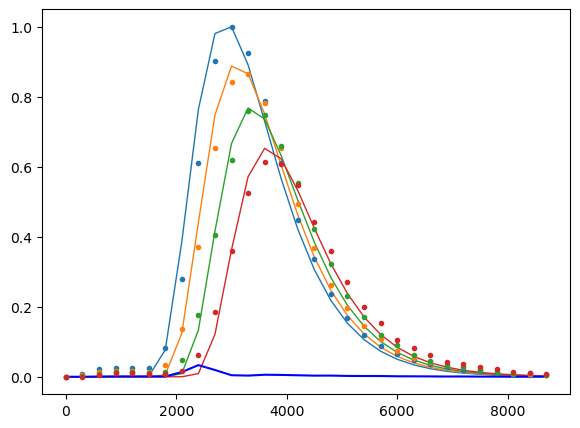

[5.66310782e-05 8.27927847e-11 1.20601434e+00 1.42959784e+00
 3.37004795e-07 1.70590259e+00] 2.7950015295738098


np.float64(2.7950015295738098)

In [ ]:
mct_obj([0.33307913, 0.63933083, 0.25751792,
       0.5369973 , 0.84254536, 0.67613873])

In [ ]:
results = calculate_velocities(
[0.33307913, 0.25751792,
       0.5369973 , 0.84254536, 0.67613873],  
    [1, 2] 
)

print(results)

        Tube  Area (m^2)  Velocity (mm/min)
0      Tube1    1.000000           3.397865
1  mct2_relA    1.206014           2.817433
2  mct3_relA    1.429598           2.376798


In [23]:
(3.397865+2.817433+ 2.376798)/3

2.864032

In [22]:
import pandas as pd
import numpy as np

# Original data
data = {
    "Tube": ["Tube1", "mct2_relA", "mct3_relA"],
    "Area (m^2)": [1.0, 1.206014, 1.429598 ],
    "Velocity (mm/min)": [3.397865, 2.817433, 2.376798,],
    "Rel. Error Area (%)": [0.0, 18.40366434760298, 15.620041487963753]  # Tube1 has 0% area error
}


df = pd.DataFrame(data)

# Flow rate relative error
rel_error_Q = 2.39833917  # in %

# Convert velocities to m/s from mm/min for error calculation
df["Velocity (m/s)"] = df["Velocity (mm/min)"] / 1000 / 60

# Compute relative error in velocity
df["Rel. Error Velocity (%)"] = np.sqrt(
    (rel_error_Q ** 2) + (df["Rel. Error Area (%)"] ** 2)
)

# Compute absolute error in velocity
df["Abs. Error Velocity (m/s)"] = df["Velocity (m/s)"] * (df["Rel. Error Velocity (%)"] / 100)

# Convert absolute error back to mm/min
df["Abs. Error Velocity (mm/min)"] = df["Abs. Error Velocity (m/s)"] * 1000 * 60

# Keep only the relevant columns for display
result_df = df[[
    "Tube",
    "Velocity (mm/min)",
    "Abs. Error Velocity (mm/min)",
    "Rel. Error Velocity (%)"
]]

# Print result
print(result_df.to_string(index=False))

     Tube  Velocity (mm/min)  Abs. Error Velocity (mm/min)  Rel. Error Velocity (%)
    Tube1           3.397865                      0.081492                 2.398339
mct2_relA           2.817433                      0.522895                18.559280
mct3_relA           2.376798                      0.375608                15.803092


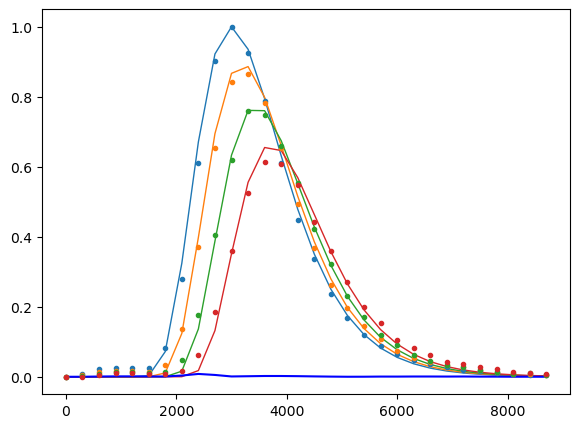

[6.27815813e-05 1.28573621e+00 1.50935734e+00 2.40709314e-07
 1.40921595e+00] 1.0513789756085865
Optimization terminated successfully.
         Current function value: 1.051379
         Iterations: 173
         Function evaluations: 332


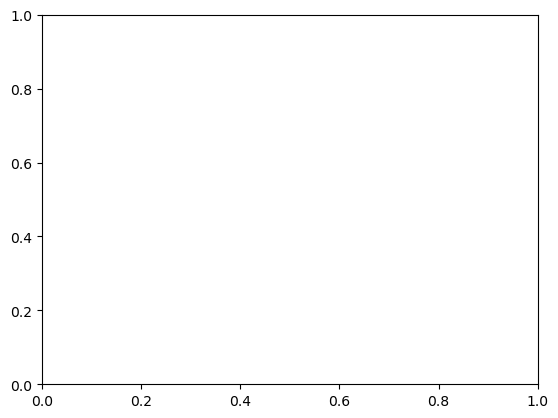

In [ ]:
x0 = np.array(
[0.33307913, 0.25751792,
       0.5369973 , 0.84254536, 0.67613873])



# Initialize the plot
fig, ax = plt.subplots()

fig.canvas.draw()
display.display(fig)

result_nm = minimize(
    fun=mct_obj,
    x0=x0,
    method='Nelder-Mead',
    bounds=(5*((0,1),)),
    options={'disp':True, 'eps':1e-1, 'finite_diff_rel_step':1e-1, 'maxiter':500},
    tol=1e-6)

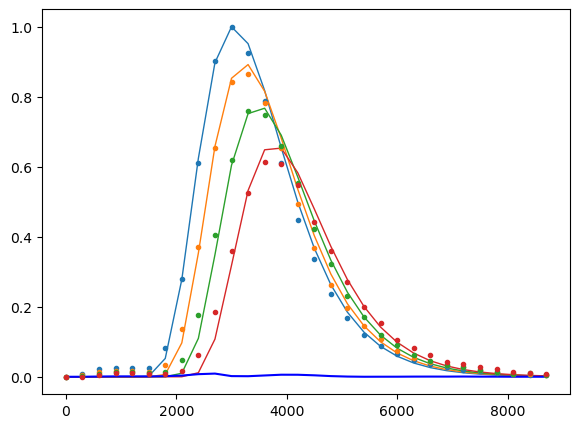

[6.27797735e-05 1.28573293e+00 1.50936054e+00 2.40703476e-07
 1.48044656e+00] 1.594367517748514


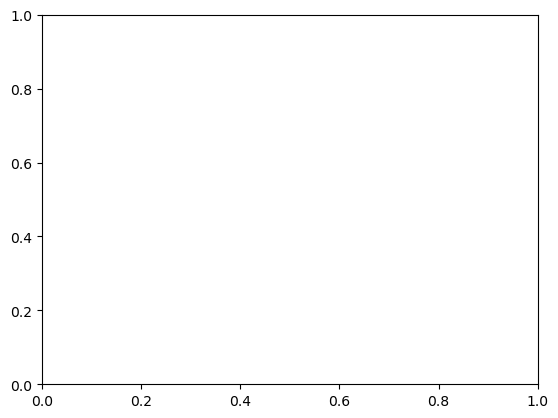

In [ ]:
x0 = result_nm.x

# Initialize the plot
fig, ax = plt.subplots()

fig.canvas.draw()
display.display(fig)

result_nm= minimize(
    fun=mct_obj,
    x0=x0,
    method='L-BFGS-B',
    jac = '3-point',
     bounds= (5*((0,1),)),
    options={'disp':True,'adaptive':True, 'maxiter': 200, 'eps':1e-1, 'finite_diff_rel_step':1e-2, 'ftol': 1e-2,'gtol': 1e-2}     ,            
    tol=1e-8)

In [ ]:
result_nm.x

array([0.37699838, 0.35716617, 0.63670067, 0.79382745, 0.65097976])

In [21]:
best_x = [0.37699838, 0.35716617, 0.63670067, 0.79382745, 0.65097976]

In [22]:
def plot_pretty(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+60,60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]



    lenghts = [x / 1000 for x in xi]

    eval_location1 = [0]
    eval_location2 = [0]
    eval_location3 = [0] + [xi[3]/1000-xi[2]/1000]


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 =  np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 =  np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 =  np.sum(cb_mct3, axis=2).squeeze()




    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3))
    calc_data = calc_data/np.max(calc_data)
  
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14) 
    
    plt.plot(calc_data, label="Simulated Data", linewidth=1.5)
    plt.gca().set_prop_cycle(None)
    plt.plot(t,exp_data, '.',  markersize=8,label="Experimental Data",)
    
    plt.xlabel("Time [min]")
    plt.ylabel("Activity [a.u.]")
    
    
    # Remove duplicate labels while keeping the first occurrence
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = {}
    unique_handles = []

    for handle, label in zip(handles, labels):
        if label not in unique_labels:  # Keep first occurrence
            unique_labels[label] = handle
            unique_handles.append(handle)

    # Add legend with unique labels
    plt.legend(unique_handles, unique_labels.keys(), fontsize=10)
    
    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    
    plt.savefig("mct_local.pdf", format="pdf")  

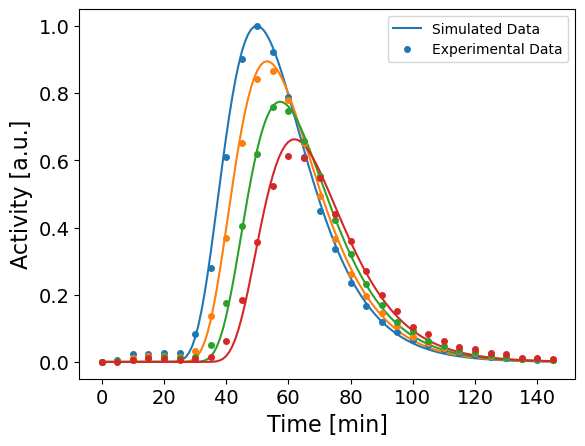

In [23]:
plot_pretty(best_x)

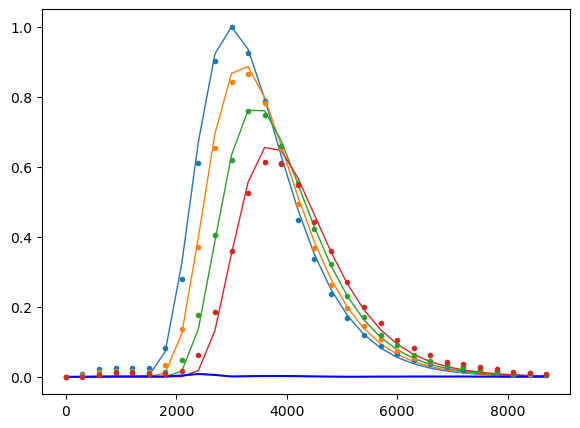

[6.27797732e-05 1.28573294e+00 1.50936054e+00 2.40703469e-07
 1.40897639e+00] 1.0513725005512122
Parameter 0: ±0.33543068482071475%
Parameter 1: ±18.40366434760298%
Parameter 2: ±15.620041487963753%
Parameter 3: ±0.1368470854688264%
Parameter 4: ±0.0%


In [ ]:
x_best_fit = best_x


def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.pinv(J.T @ J)
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")